# Student Academic Performance Prediction
## Predicting GPA Using Linear Regression, Decision Trees, and Random Forest

**Mission:** To increase access to quality tech education for young Africans by building inclusive tech academies equipped with the best tutoring tools, empowering the next generation of African innovators through data-driven learning support systems.

**Dataset Source:** [Kaggle — Student Performance Factors](https://www.kaggle.com/datasets/lainguyn123/student-performance-factors)  
**Problem:** Predict a student's GPA based on study habits, attendance, tutoring effectiveness, and parental involvement — enabling tech academies to identify which students need additional support and allocate tutoring resources where they matter most.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load and Explore the Dataset

In [2]:
df = pd.read_csv('D:\DATA ANALYSIIS\Mobile-App-Regression-Analysis\linear_regression_model\summative\linear_regression\Student_performance_data _.csv')
print('Shape:', df.shape)
df.head()

Shape: (2392, 15)


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [3]:
print('Data Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())
print('\nBasic Statistics:')
df.describe()

Data Types:
StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass           float64
dtype: object

Missing Values:
StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

Basic Statistics:


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


## 3. Data Visualizations

### 3.1 Correlation Heatmap
This reveals which features are most correlated with GPA, guiding feature selection and engineering.

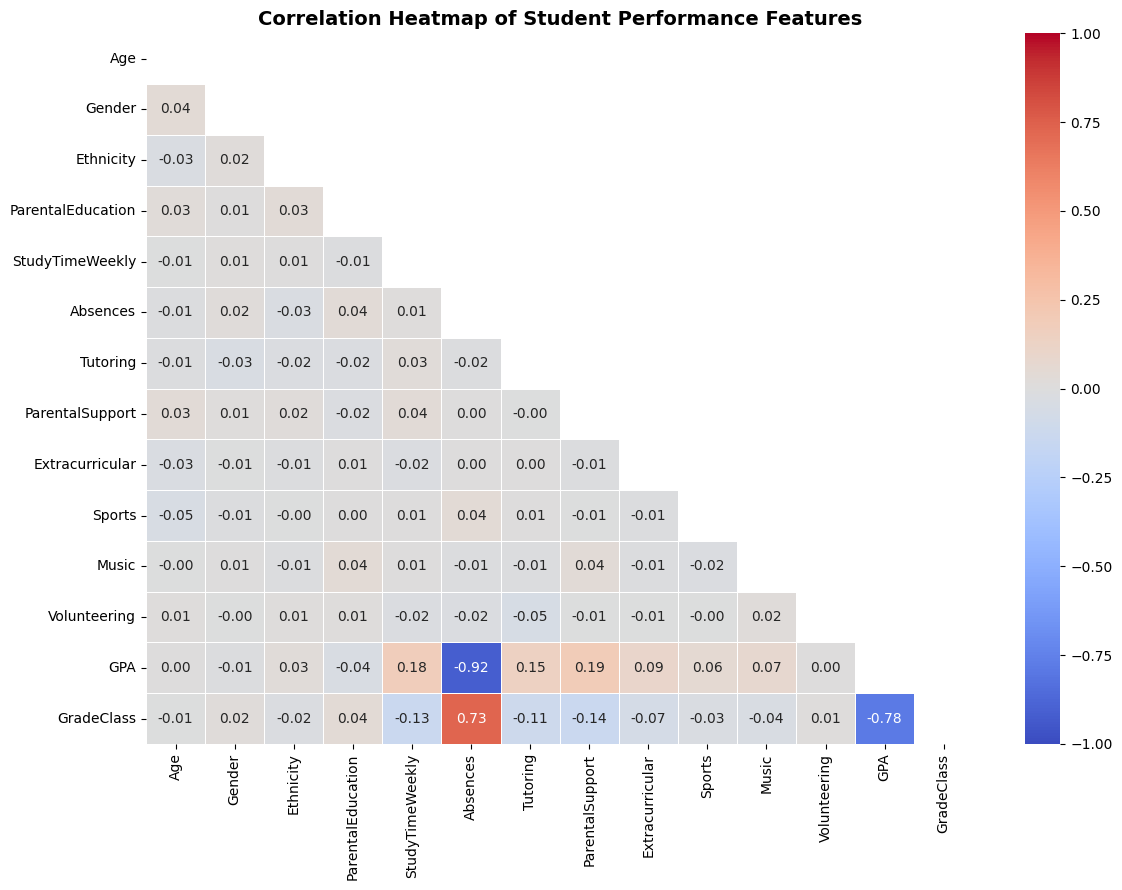


Top correlations with GPA:
ParentalSupport      0.190774
StudyTimeWeekly      0.179275
Tutoring             0.145119
Extracurricular      0.094078
Music                0.073318
Sports               0.057859
Ethnicity            0.027760
Volunteering         0.003258
Age                  0.000275
Gender              -0.013360
ParentalEducation   -0.035854
GradeClass          -0.782835
Absences            -0.919314
Name: GPA, dtype: float64


In [4]:
plt.figure(figsize=(12, 9))
corr = df.drop(columns=['StudentID']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Student Performance Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('\nTop correlations with GPA:')
print(corr['GPA'].sort_values(ascending=False).drop('GPA'))

**Interpretation:** `Absences` has a strong **negative** correlation with GPA. `StudyTimeWeekly` has a strong **positive** correlation. `GradeClass` is nearly perfectly correlated (it is derived from GPA, so it will be dropped to prevent data leakage).

### 3.2 Distribution Plots and Scatter Plots

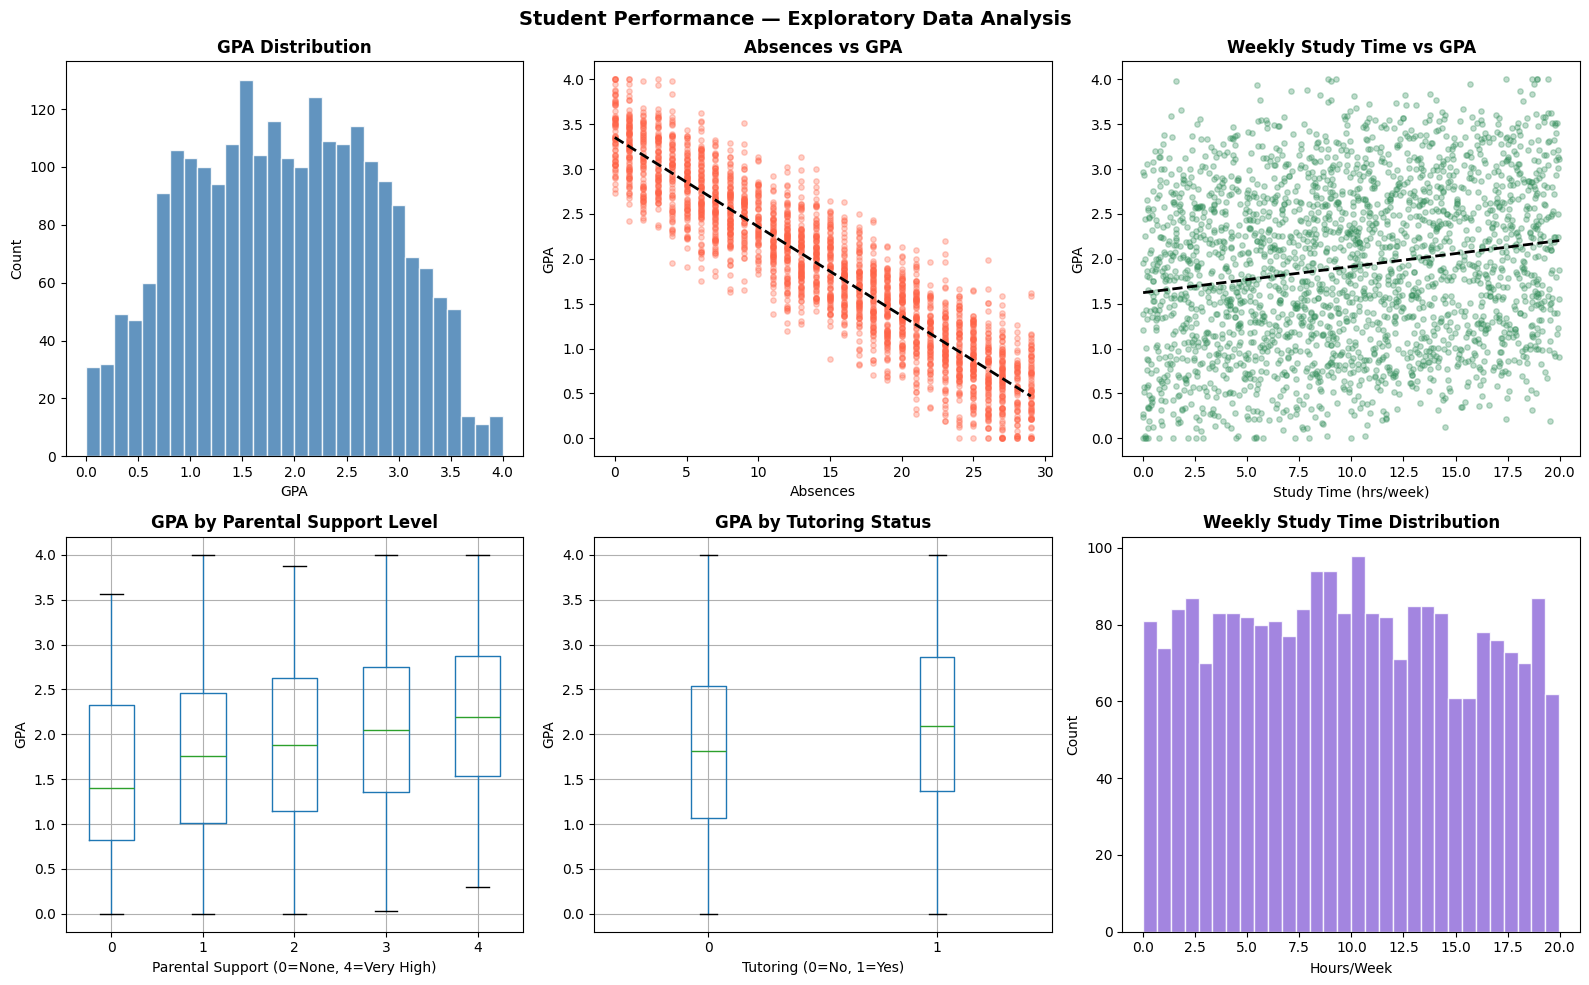

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# GPA distribution
axes[0, 0].hist(df['GPA'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0, 0].set_title('GPA Distribution', fontweight='bold')
axes[0, 0].set_xlabel('GPA')
axes[0, 0].set_ylabel('Count')

# Absences vs GPA
axes[0, 1].scatter(df['Absences'], df['GPA'], alpha=0.3, color='tomato', s=15)
axes[0, 1].set_title('Absences vs GPA', fontweight='bold')
axes[0, 1].set_xlabel('Absences')
axes[0, 1].set_ylabel('GPA')
m, b = np.polyfit(df['Absences'], df['GPA'], 1)
axes[0, 1].plot(sorted(df['Absences']), [m*x+b for x in sorted(df['Absences'])], 'k--', lw=2)

# StudyTimeWeekly vs GPA
axes[0, 2].scatter(df['StudyTimeWeekly'], df['GPA'], alpha=0.3, color='seagreen', s=15)
axes[0, 2].set_title('Weekly Study Time vs GPA', fontweight='bold')
axes[0, 2].set_xlabel('Study Time (hrs/week)')
axes[0, 2].set_ylabel('GPA')
m2, b2 = np.polyfit(df['StudyTimeWeekly'], df['GPA'], 1)
x_line = np.linspace(df['StudyTimeWeekly'].min(), df['StudyTimeWeekly'].max(), 100)
axes[0, 2].plot(x_line, m2*x_line+b2, 'k--', lw=2)

# GPA by Parental Support
df.boxplot(column='GPA', by='ParentalSupport', ax=axes[1, 0])
axes[1, 0].set_xlabel('Parental Support (0=None, 4=Very High)')
axes[1, 0].set_ylabel('GPA')
plt.sca(axes[1, 0])
plt.title('GPA by Parental Support Level', fontweight='bold')

# GPA by Tutoring
df.boxplot(column='GPA', by='Tutoring', ax=axes[1, 1])
axes[1, 1].set_xlabel('Tutoring (0=No, 1=Yes)')
axes[1, 1].set_ylabel('GPA')
plt.sca(axes[1, 1])
plt.title('GPA by Tutoring Status', fontweight='bold')

# StudyTime distribution
axes[1, 2].hist(df['StudyTimeWeekly'], bins=30, color='mediumpurple', edgecolor='white', alpha=0.85)
axes[1, 2].set_title('Weekly Study Time Distribution', fontweight='bold')
axes[1, 2].set_xlabel('Hours/Week')
axes[1, 2].set_ylabel('Count')

plt.suptitle('Student Performance — Exploratory Data Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:**
- GPA is roughly uniformly distributed across the 0–4 range.
- Absences has a clear **negative** trend with GPA — more missed classes = lower grades.
- Weekly study time has a **positive** trend — students who study more earn higher GPAs.
- Students receiving tutoring have a noticeably higher median GPA.
- Higher parental support levels are associated with progressively higher GPA quartiles.

## 4. Feature Engineering

In [6]:

df_model = df.drop(columns=['StudentID', 'GradeClass']).copy()

print('Columns to convert to numeric: None — all features are already numeric.')
print('\nEncoding reference:')
print('  Gender:            0=Female, 1=Male (binary encoded)')
print('  Ethnicity:         0-3 (label encoded categorical)')
print('  ParentalEducation: 0-4 (ordinal encoded)')
print('  ParentalSupport:   0-4 (ordinal encoded)')
print('  Tutoring/Sports/Music/Volunteering/Extracurricular: binary 0/1')

df_model['StudyEfficiency'] = df_model['StudyTimeWeekly'] / (df_model['Absences'] + 1)

df_model['EngagementScore'] = (
    df_model['Extracurricular'] + df_model['Sports'] +
    df_model['Music'] + df_model['Volunteering'] + df_model['Tutoring']
)

print('\nEngineered features added:')
print('  StudyEfficiency = StudyTimeWeekly / (Absences + 1)')
print('  EngagementScore = sum of all 5 activity participation columns')
print('\nFinal feature set:', list(df_model.drop(columns=['GPA']).columns))

Columns to convert to numeric: None — all features are already numeric.

Encoding reference:
  Gender:            0=Female, 1=Male (binary encoded)
  Ethnicity:         0-3 (label encoded categorical)
  ParentalEducation: 0-4 (ordinal encoded)
  ParentalSupport:   0-4 (ordinal encoded)
  Tutoring/Sports/Music/Volunteering/Extracurricular: binary 0/1

Engineered features added:
  StudyEfficiency = StudyTimeWeekly / (Absences + 1)
  EngagementScore = sum of all 5 activity participation columns

Final feature set: ['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'StudyEfficiency', 'EngagementScore']


## 5. Prepare X and y

In [7]:
X = df_model.drop(columns=['GPA'])
y = df_model['GPA']

print('Feature matrix X shape:', X.shape)
print('Target y shape:', y.shape)

Feature matrix X shape: (2392, 14)
Target y shape: (2392,)


## 6. Train / Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples:     {X_test.shape[0]}')

Training samples: 1913
Test samples:     479


## 7. Standardize the Data

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Standardization complete.')
print('Scaled train feature means (should be ~0):', np.round(X_train_scaled.mean(axis=0), 3))
print('Scaled train feature stds  (should be ~1):', np.round(X_train_scaled.std(axis=0), 3))

Standardization complete.
Scaled train feature means (should be ~0): [-0.  0.  0. -0.  0. -0.  0. -0. -0. -0. -0.  0.  0. -0.]
Scaled train feature stds  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 8. Model 1 — Linear Regression

In [10]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr_train = lr.predict(X_train_scaled)
y_pred_lr_test  = lr.predict(X_test_scaled)

lr_train_mse = mean_squared_error(y_train, y_pred_lr_train)
lr_test_mse  = mean_squared_error(y_test,  y_pred_lr_test)
lr_test_r2   = r2_score(y_test, y_pred_lr_test)

print('=== Linear Regression ===')
print(f'  Train MSE : {lr_train_mse:.4f}')
print(f'  Test  MSE : {lr_test_mse:.4f}')
print(f'  Test  R²  : {lr_test_r2:.4f}')
print(f'  Test  RMSE: {np.sqrt(lr_test_mse):.4f}')

=== Linear Regression ===
  Train MSE : 0.0385
  Test  MSE : 0.0387
  Test  R²  : 0.9531
  Test  RMSE: 0.1968


## 9. Model 2 — Decision Tree Regressor

In [11]:
dt = DecisionTreeRegressor(max_depth=8, min_samples_split=10, random_state=42)
dt.fit(X_train_scaled, y_train)

y_pred_dt_train = dt.predict(X_train_scaled)
y_pred_dt_test  = dt.predict(X_test_scaled)

dt_train_mse = mean_squared_error(y_train, y_pred_dt_train)
dt_test_mse  = mean_squared_error(y_test,  y_pred_dt_test)
dt_test_r2   = r2_score(y_test, y_pred_dt_test)

print('=== Decision Tree Regressor ===')
print(f'  Train MSE : {dt_train_mse:.4f}')
print(f'  Test  MSE : {dt_test_mse:.4f}')
print(f'  Test  R²  : {dt_test_r2:.4f}')
print(f'  Test  RMSE: {np.sqrt(dt_test_mse):.4f}')

=== Decision Tree Regressor ===
  Train MSE : 0.0368
  Test  MSE : 0.0888
  Test  R²  : 0.8926
  Test  RMSE: 0.2981


## 10. Model 3 — Random Forest Regressor

In [12]:
rf = RandomForestRegressor(n_estimators=200, max_depth=10,
                           min_samples_split=5, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

y_pred_rf_train = rf.predict(X_train_scaled)
y_pred_rf_test  = rf.predict(X_test_scaled)

rf_train_mse = mean_squared_error(y_train, y_pred_rf_train)
rf_test_mse  = mean_squared_error(y_test,  y_pred_rf_test)
rf_test_r2   = r2_score(y_test, y_pred_rf_test)

print('=== Random Forest Regressor ===')
print(f'  Train MSE : {rf_train_mse:.4f}')
print(f'  Test  MSE : {rf_test_mse:.4f}')
print(f'  Test  R²  : {rf_test_r2:.4f}')
print(f'  Test  RMSE: {np.sqrt(rf_test_mse):.4f}')

=== Random Forest Regressor ===
  Train MSE : 0.0154
  Test  MSE : 0.0544
  Test  R²  : 0.9342
  Test  RMSE: 0.2333


## 11. Gradient Descent — Loss Curve (SGDRegressor)

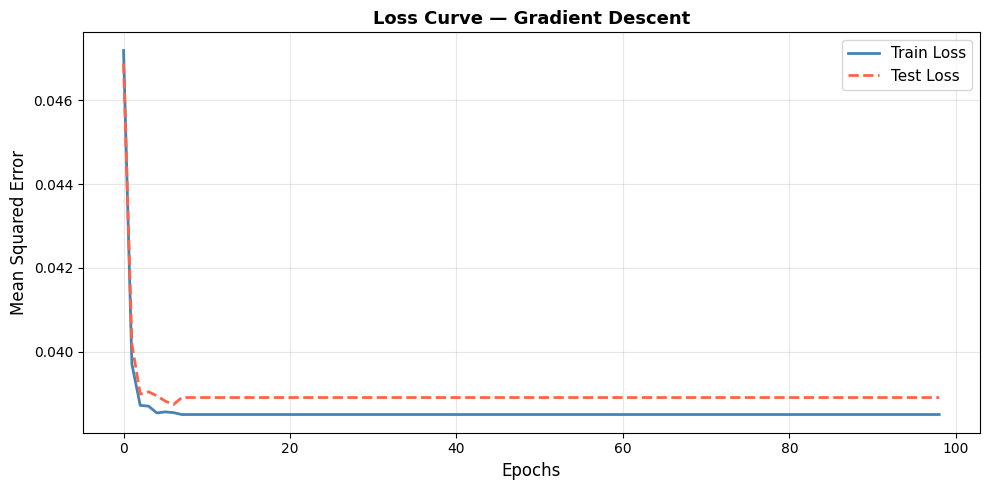

Final Train MSE: 0.0385
Final Test  MSE: 0.0389


In [13]:
train_loss = []
test_loss = []

for i in range(1, 100):
    model = SGDRegressor(max_iter=i, random_state=42)
    model.fit(X_train_scaled, y_train)

    train_loss.append(mean_squared_error(y_train, model.predict(X_train_scaled)))
    test_loss.append(mean_squared_error(y_test,  model.predict(X_test_scaled)))

plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Train Loss', color='steelblue', lw=2)
plt.plot(test_loss,  label='Test Loss',  color='tomato',    lw=2, linestyle='--')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.title('Loss Curve — Gradient Descent', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Final Train MSE: {train_loss[-1]:.4f}')
print(f'Final Test  MSE: {test_loss[-1]:.4f}')

## 12. Scatter Plot — Before and After Training (Linear Regression)

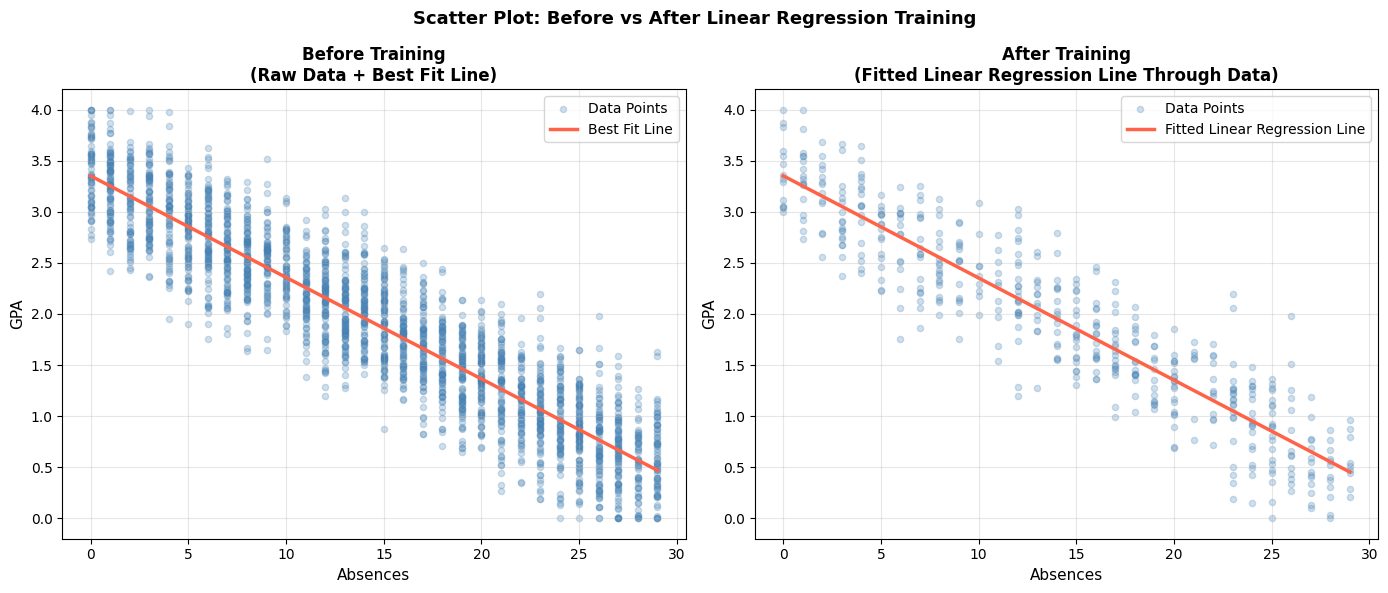

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))


axes[0].scatter(df['Absences'], df['GPA'], alpha=0.25, color='steelblue', s=20, label='Data Points')
m, b = np.polyfit(df['Absences'], df['GPA'], 1)
abs_line = np.linspace(df['Absences'].min(), df['Absences'].max(), 300)
axes[0].plot(abs_line, m * abs_line + b, color='tomato', lw=2.5, label='Best Fit Line')
axes[0].set_title('Before Training\n(Raw Data + Best Fit Line)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Absences', fontsize=11)
axes[0].set_ylabel('GPA', fontsize=11)
axes[0].legend()
axes[0].grid(alpha=0.3)


axes[1].scatter(X_test['Absences'], y_test, alpha=0.25, color='steelblue', s=20, label='Data Points')
mean_row  = X_test.mean().to_dict()
abs_range = np.linspace(X_test['Absences'].min(), X_test['Absences'].max(), 300)
abs_sweep = pd.DataFrame([{**mean_row, 'Absences': v} for v in abs_range])
lr_line   = lr.predict(scaler.transform(abs_sweep[X.columns]))
axes[1].plot(abs_range, lr_line, color='tomato', lw=2.5, label='Fitted Linear Regression Line')
axes[1].set_title('After Training\n(Fitted Linear Regression Line Through Data)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Absences', fontsize=11)
axes[1].set_ylabel('GPA', fontsize=11)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Scatter Plot: Before vs After Linear Regression Training', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. Model Comparison

In [15]:
results = pd.DataFrame({
    'Model':      ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'Train MSE':  [lr_train_mse,        dt_train_mse,    rf_train_mse],
    'Test MSE':   [lr_test_mse,         dt_test_mse,     rf_test_mse],
    'Test R2':    [lr_test_r2,          dt_test_r2,      rf_test_r2],
    'Test RMSE':  [np.sqrt(lr_test_mse), np.sqrt(dt_test_mse), np.sqrt(rf_test_mse)]
})
results = results.sort_values('Test MSE').reset_index(drop=True)
print('Model Comparison (sorted by Test MSE — lower is better):')
print(results.to_string(index=False))

best_model_name = results.iloc[0]['Model']
print(f'\nBest model: {best_model_name}')

Model Comparison (sorted by Test MSE — lower is better):
            Model  Train MSE  Test MSE  Test R2  Test RMSE
Linear Regression   0.038462  0.038746 0.953145   0.196839
    Random Forest   0.015382  0.054429 0.934179   0.233301
    Decision Tree   0.036775  0.088849 0.892556   0.298076

Best model: Linear Regression


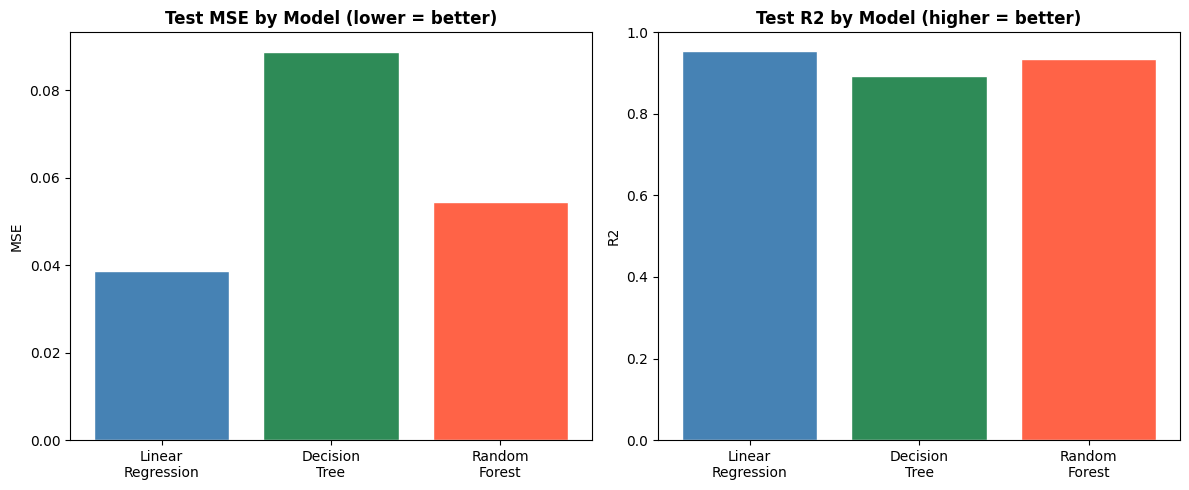

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['steelblue', 'seagreen', 'tomato']
model_labels = ['Linear\nRegression', 'Decision\nTree', 'Random\nForest']

axes[0].bar(model_labels, [lr_test_mse, dt_test_mse, rf_test_mse], color=colors, edgecolor='white')
axes[0].set_title('Test MSE by Model (lower = better)', fontweight='bold')
axes[0].set_ylabel('MSE')

axes[1].bar(model_labels, [lr_test_r2, dt_test_r2, rf_test_r2], color=colors, edgecolor='white')
axes[1].set_title('Test R2 by Model (higher = better)', fontweight='bold')
axes[1].set_ylabel('R2')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 14. Save the Best Model

In [17]:
model_map = {
    'Linear Regression': lr,
    'Decision Tree':      dt,
    'Random Forest':      rf
}
best_model = model_map[best_model_name]

joblib.dump(best_model, 'best_student_gpa_model.pkl')
joblib.dump(scaler,     'scaler.pkl')

print(f'Best model ({best_model_name}) saved as: best_student_gpa_model.pkl')
print('Scaler saved as: scaler.pkl')

Best model (Linear Regression) saved as: best_student_gpa_model.pkl
Scaler saved as: scaler.pkl


## 15. Prediction Script — Use Best Model on One Test Data Point

In [18]:
# Load saved model and scaler
loaded_model  = joblib.load('best_student_gpa_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

sample_index = X_test.index[0]
sample       = X_test.loc[[sample_index]]
actual_gpa   = y_test.loc[sample_index]

print('Sample student features:')
print(sample.T.to_string())

# Scale and predict
sample_scaled = loaded_scaler.transform(sample)
predicted_gpa = loaded_model.predict(sample_scaled)[0]

print(f'\n--- Prediction Result ---')
print(f'Actual GPA:     {actual_gpa:.4f}')
print(f'Predicted GPA:  {predicted_gpa:.4f}')
print(f'Absolute Error: {abs(actual_gpa - predicted_gpa):.4f}')

Sample student features:
                        1004
Age                15.000000
Gender              1.000000
Ethnicity           2.000000
ParentalEducation   4.000000
StudyTimeWeekly     0.135763
Absences           17.000000
Tutoring            0.000000
ParentalSupport     2.000000
Extracurricular     0.000000
Sports              1.000000
Music               1.000000
Volunteering        1.000000
StudyEfficiency     0.007542
EngagementScore     3.000000

--- Prediction Result ---
Actual GPA:     1.4277
Predicted GPA:  1.4772
Absolute Error: 0.0495
